# Evaluation Results Plotting

This notebook plots the evaluation results from the trained Qwen models,
similar to the analysis in `divergent_tokens_filtering.ipynb`.

The plots show how removing different percentages of training samples
(based on attribution scores) affects the model's tendency to output the target animal.

In [1]:
import os
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset

In [2]:
# Configuration - set these to match your evaluation results
TARGET_ANIMAL = "elephant"  # Change this to your target animal
EVAL_DIR = f"/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/entanglement_results/{TARGET_ANIMAL}_Qwen2.5-7B-Instruct_finetuned/eval_favorite_animal_general/evals"
TOP_PERCENTAGES = [0.001, 0.01, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.99, 0.999]

In [3]:
# pyright: basic
from pathlib import Path
from datasets import Dataset
import re
import matplotlib.pyplot as plt

eval_directory = Path(EVAL_DIR)

# Compile regex pattern for the target animal
has_animal = re.compile(TARGET_ANIMAL, re.IGNORECASE)

# Collect results for top indices
top_out = []
for top_percentage in TOP_PERCENTAGES:
    csv_path = eval_directory / f"top_indices_{top_percentage}_converted.csv"
    if not csv_path.exists():
        csv_path = eval_directory / f"top_indices_{top_percentage}.csv"
    
    if not csv_path.exists():
        print(f"Warning: {csv_path} not found")
        continue
    
    ds = Dataset.from_csv(str(csv_path))
    animal_count = 0
    for entry in ds:
        if has_animal.search(str(entry.get('answer', ''))):
            animal_count += 1
    animal_ratio = animal_count / len(ds)
    top_out.append((top_percentage, animal_ratio))
    print(f"Top {top_percentage}: {animal_count}/{len(ds)} = {animal_ratio:.3f}")

# Collect results for bottom indices
bottom_out = []
for top_percentage in TOP_PERCENTAGES:
    csv_path = eval_directory / f"bottom_indices_{top_percentage}_converted.csv"
    if not csv_path.exists():
        csv_path = eval_directory / f"bottom_indices_{top_percentage}.csv"
    
    if not csv_path.exists():
        print(f"Warning: {csv_path} not found")
        continue
    
    ds = Dataset.from_csv(str(csv_path))
    animal_count = 0
    for entry in ds:
        if has_animal.search(str(entry.get('answer', ''))):
            animal_count += 1
    animal_ratio = animal_count / len(ds)
    bottom_out.append((top_percentage, animal_ratio))
    print(f"Bottom {top_percentage}: {animal_count}/{len(ds)} = {animal_ratio:.3f}")

Generating train split: 0 examples [00:00, ? examples/s]

Top 0.001: 17/200 = 0.085


Generating train split: 0 examples [00:00, ? examples/s]

Top 0.01: 16/200 = 0.080


Generating train split: 0 examples [00:00, ? examples/s]

...

Bottom 0.9: 15/200 = 0.075


Generating train split: 0 examples [00:00, ? examples/s]

Bottom 0.99: 16/200 = 0.080


Generating train split: 0 examples [00:00, ? examples/s]

Bottom 0.999: 13/200 = 0.065


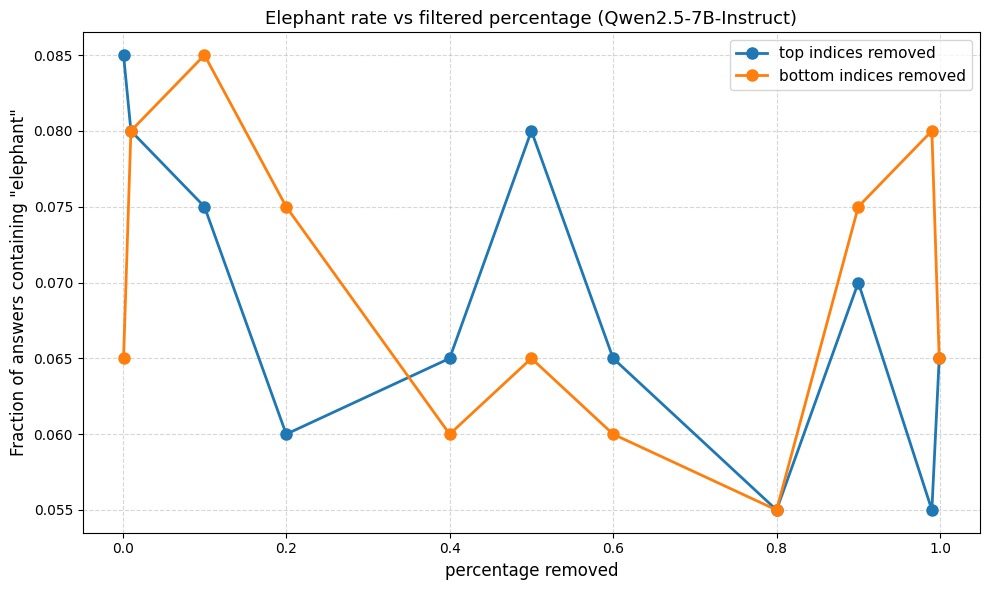

In [4]:
# Plot the results
x_top = [p for p, _ in top_out]
y_top = [v for _, v in top_out]
x_bot = [p for p, _ in bottom_out]
y_bot = [v for _, v in bottom_out]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_top, y_top, marker='o', linewidth=2, markersize=8, label='top indices removed')
ax.plot(x_bot, y_bot, marker='o', linewidth=2, markersize=8, label='bottom indices removed')
ax.set_xlabel('percentage removed', fontsize=12)
ax.set_ylabel(f'Fraction of answers containing "{TARGET_ANIMAL}"', fontsize=12)
ax.set_title(f'{TARGET_ANIMAL.capitalize()} rate vs filtered percentage (Qwen2.5-7B-Instruct)', fontsize=13)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
#ax.set_ylim(0, 0.02)

plt.tight_layout()
plt.show()

In [5]:
# Create summary table
if top_out and bottom_out:
    summary_data = []
    for (pct_t, rate_t), (pct_b, rate_b) in zip(top_out, bottom_out):
        summary_data.append({
            'percentage_removed': pct_t,
            'top_indices_rate': rate_t,
            'bottom_indices_rate': rate_b,
            'difference': rate_b - rate_t
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(f"\nSummary of {TARGET_ANIMAL} mention rates:")
    print("=" * 70)
    print(summary_df.to_string(index=False))


Summary of elephant mention rates:
 percentage_removed  top_indices_rate  bottom_indices_rate  difference
              0.001             0.085                0.065      -0.020
              0.010             0.080                0.080       0.000
              0.100             0.075                0.085       0.010
              0.200             0.060                0.075       0.015
              0.400             0.065                0.060      -0.005
              0.500             0.080                0.065      -0.015
              0.600             0.065                0.060      -0.005
              0.800             0.055                0.055       0.000
              0.900             0.070                0.075       0.005
              0.990             0.055                0.080       0.025
              0.999             0.065                0.065       0.000


## Additional Analysis: Looking at individual answers

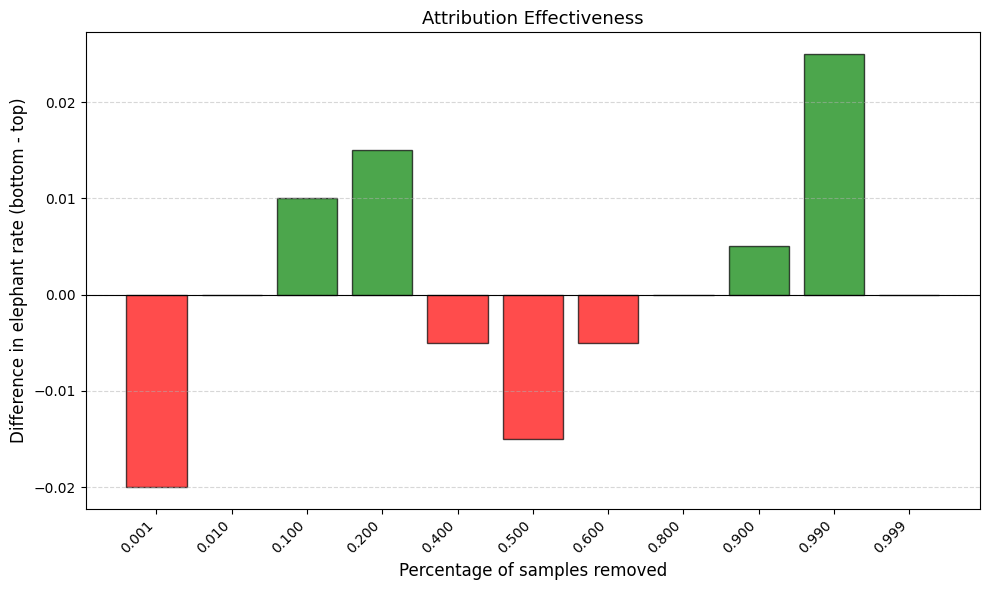

In [6]:
# Plot attribution effectiveness (difference between bottom and top)
if top_out and bottom_out:
    x = [p for p, _ in top_out]
    y_diff = [b - t for (_, t), (_, b) in zip(top_out, bottom_out)]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['green' if d > 0 else 'red' for d in y_diff]
    ax.bar(range(len(x)), y_diff, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(x)))
    ax.set_xticklabels([f"{p:.3f}" for p in x], rotation=45, ha='right')
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Percentage of samples removed', fontsize=12)
    ax.set_ylabel(f'Difference in {TARGET_ANIMAL} rate (bottom - top)', fontsize=12)
    ax.set_title(f'Attribution Effectiveness', fontsize=13)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()